<a href="https://colab.research.google.com/github/mehaklaha/BYOD-CHATBOT/blob/main/LaB10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import SpectralClustering

%matplotlib inline

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data"

df = pd.read_csv(url, header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       690 non-null    object 
 1   1       690 non-null    object 
 2   2       690 non-null    float64
 3   3       690 non-null    object 
 4   4       690 non-null    object 
 5   5       690 non-null    object 
 6   6       690 non-null    object 
 7   7       690 non-null    float64
 8   8       690 non-null    object 
 9   9       690 non-null    object 
 10  10      690 non-null    int64  
 11  11      690 non-null    object 
 12  12      690 non-null    object 
 13  13      690 non-null    object 
 14  14      690 non-null    int64  
 15  15      690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


,2,7,10,14
count,690.000000,690.000000,690.00000,690.000000
mean,4.758725,2.223406,2.40000,1017.385507
std,4.978163,3.346513,4.86294,5210.102598
min,0.000000,0.000000,0.00000,0.000000
25%,1.000000,0.165000,0.00000,0.000000
50%,2.750000,1.000000,0.00000,5.000000
75%,7.207500,2.625000,3.00000,395.500000
max,28.000000,28.500000,67.00000,100000.000000


In [4]:
df.replace('?', np.nan, inplace=True)

df = df.dropna()

In [5]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1,153,0.000,1,0,12,7,1.25,1,1,1,0,0,68,0,0
1,0,321,4.460,1,0,10,3,3.04,1,1,6,0,0,11,560,0
2,0,88,0.500,1,0,10,3,1.50,1,0,0,0,0,94,824,0
3,1,123,1.540,1,0,12,7,3.75,1,1,5,1,0,31,3,0
4,1,42,5.625,1,0,12,7,1.71,1,0,0,0,2,37,0,0


In [6]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1,153,0.000,1,0,12,7,1.25,1,1,1,0,0,68,0,0
1,0,321,4.460,1,0,10,3,3.04,1,1,6,0,0,11,560,0
2,0,88,0.500,1,0,10,3,1.50,1,0,0,0,0,94,824,0
3,1,123,1.540,1,0,12,7,3.75,1,1,5,1,0,31,3,0
4,1,42,5.625,1,0,12,7,1.71,1,0,0,0,2,37,0,0


In [7]:
X = df_encoded.values

print("Shape:", X.shape)

Shape: (653, 16)


In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(X)

labels = kmeans.labels_
centers = kmeans.cluster_centers_

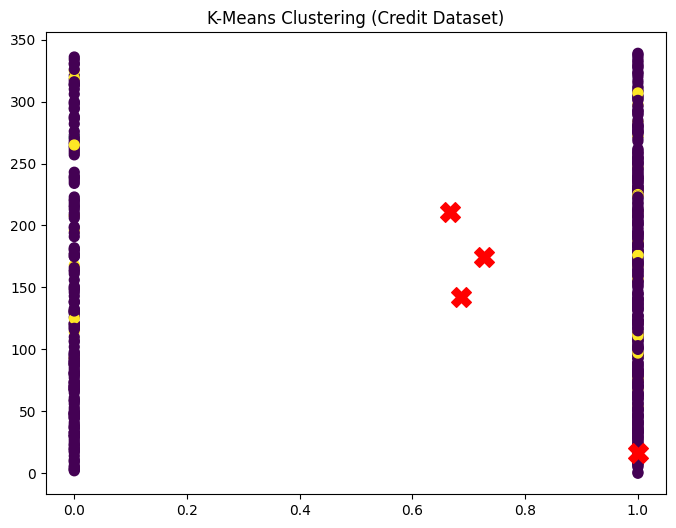

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')

plt.scatter(centers[:, 0], centers[:, 1],
            c='red', s=200, marker='X')

plt.title("K-Means Clustering (Credit Dataset)")
plt.show()

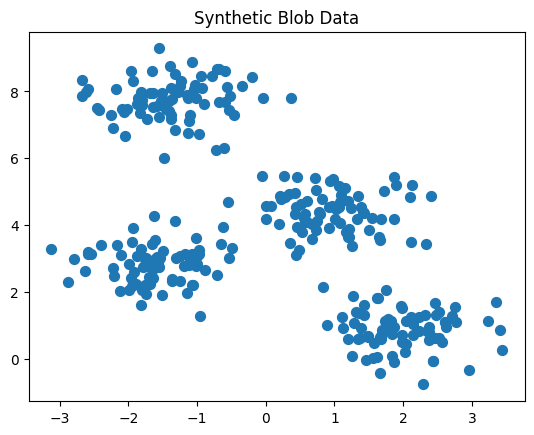

In [10]:
X_blob, y_blob = make_blobs(n_samples=300, centers=4,
                           cluster_std=0.60, random_state=0)

plt.scatter(X_blob[:, 0], X_blob[:, 1], s=50)
plt.title("Synthetic Blob Data")
plt.show()

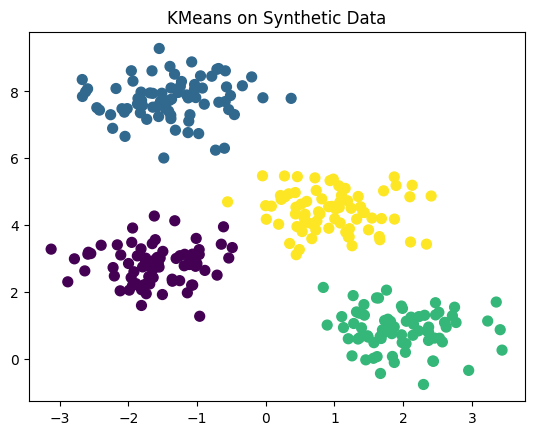

In [11]:
kmeans_blob = KMeans(n_clusters=4)

labels_blob = kmeans_blob.fit_predict(X_blob)

plt.scatter(X_blob[:, 0], X_blob[:, 1],
            c=labels_blob, s=50, cmap='viridis')

plt.title("KMeans on Synthetic Data")
plt.show()

In [12]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        labels = pairwise_distances_argmin(X, centers)

        new_centers = np.array([
            X[labels == i].mean(0)
            for i in range(n_clusters)
        ])

        if np.all(centers == new_centers):
            break

        centers = new_centers

    return centers, labels

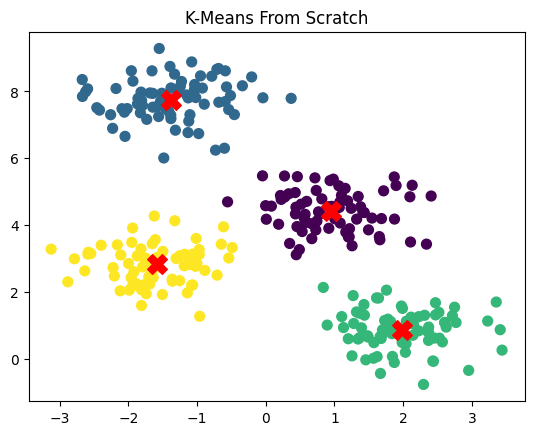

In [13]:
centers_custom, labels_custom = find_clusters(X_blob, 4)

plt.scatter(X_blob[:, 0], X_blob[:, 1],
            c=labels_custom, s=50, cmap='viridis')

plt.scatter(centers_custom[:, 0], centers_custom[:, 1],
            c='red', s=200, marker='X')

plt.title("K-Means From Scratch")
plt.show()

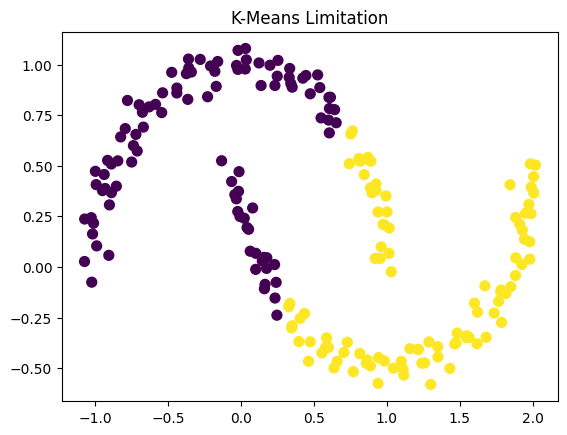

In [14]:
X_moon, y_moon = make_moons(200, noise=0.05, random_state=0)

labels_moon = KMeans(2).fit_predict(X_moon)

plt.scatter(X_moon[:, 0], X_moon[:, 1],
            c=labels_moon, s=50, cmap='viridis')

plt.title("K-Means Limitation")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


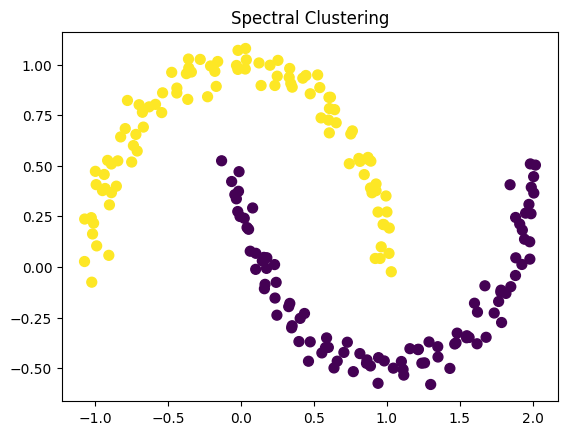

In [15]:
model = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    assign_labels='kmeans'
)

labels_spec = model.fit_predict(X_moon)

plt.scatter(X_moon[:, 0], X_moon[:, 1],
            c=labels_spec, s=50, cmap='viridis')

plt.title("Spectral Clustering")
plt.show()